<a href="https://colab.research.google.com/github/tayrault/Flipkart/blob/main/Flipkart_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
Flipkart project decription here: https://github.com/tayrault/Flipkart
The objective in this notebook is to clean, explore and predict
```



# Data cleaning

In [ ]:
# import file Google drive
!gdown '1qrhH4uxxrQmYQY3F4NC0wo2kqCDB9CLM8BpJrzMcmqo'

Downloading...
From (original): https://drive.google.com/uc?id=1qrhH4uxxrQmYQY3F4NC0wo2kqCDB9CLM8BpJrzMcmqo
From (redirected): https://docs.google.com/spreadsheets/d/1qrhH4uxxrQmYQY3F4NC0wo2kqCDB9CLM8BpJrzMcmqo/export?format=xlsx
To: /content/Flipkart_csv_import.xlsx
11.6MB [00:00, 64.7MB/s]


In [ ]:
import pandas as pd
df = pd.read_excel('/content/Flipkart_csv_import.xlsx')
df.head()

,product_id,product_name,category,brand,seller,seller_city,price,discount_percent,final_price,rating,...,weight_g,warranty_months,color,size,return_policy_days,is_returnable,payment_modes,shipping_weight_g,product_score,seller_rating
0,FKP0000001,Adidas Ultra 664,Toys,Adidas,MegaStore,Hyderabad,35547.34,15,30215.24,1.9,...,3038.23,36,Green,XL,30,True,"COD,CARD",3483.592454,6.78,3.28
1,FKP0000002,LG Series 124,Fashion,LG,ValueKart,Mumbai,30693.79,10,27624.41,3.2,...,1921.82,0,Grey,One Size,7,True,"UPI,CARD",2091.473835,50.78,3.42
2,FKP0000003,Redmi Model 35,Beauty,Redmi,SmartDeals,Ahmedabad,51214.50,40,30728.70,4.4,...,1143.49,12,Black,M,0,False,"COD,UPI,CARD",1242.770494,4.24,4.23
3,FKP0000004,Sony Edition 769,Toys,Sony,UrbanRetails,Delhi,33168.49,30,23217.94,2.8,...,3644.81,24,Black,L,0,False,"CARD,Wallet",3891.222716,1.38,3.45
4,FKP0000005,Boat Prime 291,Home & Kitchen,Boat,RetailHub,Pune,14181.34,0,14181.34,3.7,...,310.33,0,Blue,NaN,30,True,"CARD,Wallet",386.061014,79.27,4.90


In [ ]:
# See its shape
df.shape

(80000, 25)

In [ ]:
# Objects to convert to string
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   product_id          80000 non-null  object        
 1   product_name        80000 non-null  object        
 2   category            80000 non-null  object        
 3   brand               80000 non-null  object        
 4   seller              80000 non-null  object        
 5   seller_city         80000 non-null  object        
 6   price               80000 non-null  float64       
 7   discount_percent    80000 non-null  int64         
 8   final_price         80000 non-null  float64       
 9   rating              80000 non-null  float64       
 10  review_count        80000 non-null  int64         
 11  stock_available     80000 non-null  int64         
 12  units_sold          80000 non-null  int64         
 13  listing_date        80000 non-null  datetime64

<Axes: >

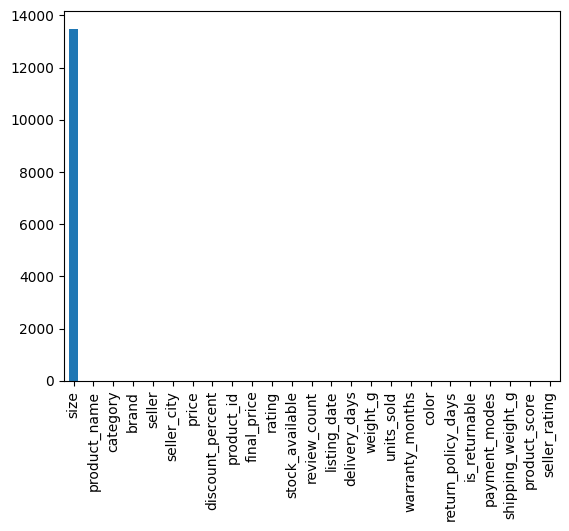

In [ ]:
# size 13K null values identified
df.isnull().sum()
df.isnull().sum().sort_values(ascending=False).plot(kind='bar')


In [ ]:
# Changing object to string for size
df_clean = df.copy()
df_clean['size'] = df_clean['size'].astype('string')
df_clean['size'].unique()

<StringArray>
['XL', 'One Size', 'M', 'L', <NA>, 'S']
Length: 6, dtype: string

In [ ]:
# Transform NaN/One size into unique_size
df_clean.replace({'nan': 'One Size'}, inplace=True)
df_clean.replace({'One Size': 'unique_size'}, inplace=True)
df_clean['size'] = df_clean['size'].fillna('unique-size')
df_clean.head()

,product_id,product_name,category,brand,seller,seller_city,price,discount_percent,final_price,rating,...,weight_g,warranty_months,color,size,return_policy_days,is_returnable,payment_modes,shipping_weight_g,product_score,seller_rating
0,FKP0000001,Adidas Ultra 664,Toys,Adidas,MegaStore,Hyderabad,35547.34,15,30215.24,1.9,...,3038.23,36,Green,XL,30,True,"COD,CARD",3483.592454,6.78,3.28
1,FKP0000002,LG Series 124,Fashion,LG,ValueKart,Mumbai,30693.79,10,27624.41,3.2,...,1921.82,0,Grey,unique_size,7,True,"UPI,CARD",2091.473835,50.78,3.42
2,FKP0000003,Redmi Model 35,Beauty,Redmi,SmartDeals,Ahmedabad,51214.50,40,30728.70,4.4,...,1143.49,12,Black,M,0,False,"COD,UPI,CARD",1242.770494,4.24,4.23
3,FKP0000004,Sony Edition 769,Toys,Sony,UrbanRetails,Delhi,33168.49,30,23217.94,2.8,...,3644.81,24,Black,L,0,False,"CARD,Wallet",3891.222716,1.38,3.45
4,FKP0000005,Boat Prime 291,Home & Kitchen,Boat,RetailHub,Pune,14181.34,0,14181.34,3.7,...,310.33,0,Blue,unique-size,30,True,"CARD,Wallet",386.061014,79.27,4.90


In [ ]:
# Check, no more null values
df_clean.isnull().sum()

,0
product_id,0
product_name,0
category,0
brand,0
seller,0
seller_city,0
price,0
discount_percent,0
final_price,0
rating,0


In [ ]:
df_clean.head()

,product_id,product_name,category,brand,seller,seller_city,price,discount_percent,final_price,rating,...,weight_g,warranty_months,color,size,return_policy_days,is_returnable,payment_modes,shipping_weight_g,product_score,seller_rating
0,FKP0000001,Adidas Ultra 664,Toys,Adidas,MegaStore,Hyderabad,35547.34,15,30215.24,1.9,...,3038.23,36,Green,XL,30,True,"COD,CARD",3483.592454,6.78,3.28
1,FKP0000002,LG Series 124,Fashion,LG,ValueKart,Mumbai,30693.79,10,27624.41,3.2,...,1921.82,0,Grey,unique_size,7,True,"UPI,CARD",2091.473835,50.78,3.42
2,FKP0000003,Redmi Model 35,Beauty,Redmi,SmartDeals,Ahmedabad,51214.50,40,30728.70,4.4,...,1143.49,12,Black,M,0,False,"COD,UPI,CARD",1242.770494,4.24,4.23
3,FKP0000004,Sony Edition 769,Toys,Sony,UrbanRetails,Delhi,33168.49,30,23217.94,2.8,...,3644.81,24,Black,L,0,False,"CARD,Wallet",3891.222716,1.38,3.45
4,FKP0000005,Boat Prime 291,Home & Kitchen,Boat,RetailHub,Pune,14181.34,0,14181.34,3.7,...,310.33,0,Blue,unique-size,30,True,"CARD,Wallet",386.061014,79.27,4.90


In [ ]:
# This file has been reinjected into BigQuery
df_clean.to_csv("Flipkart_csv_import_cleaned", index=True)

# Data Exploration

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings


In [ ]:
df_clean = df

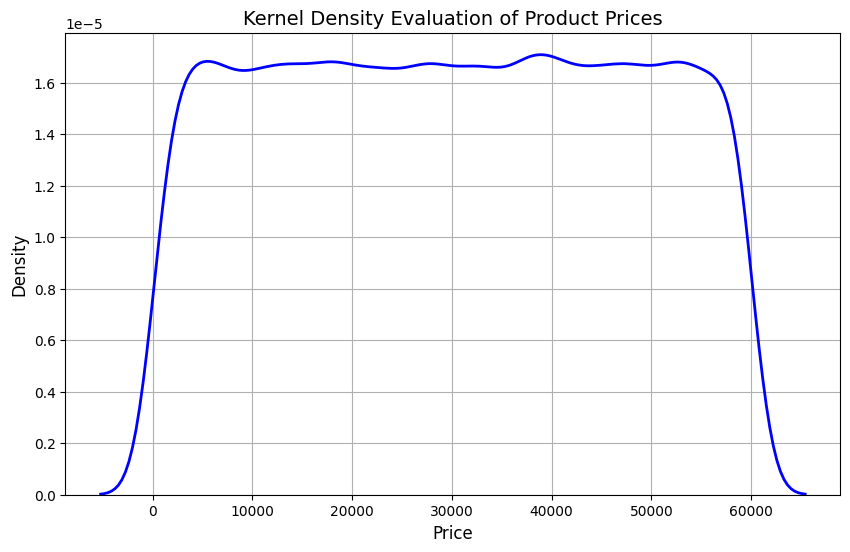

In [ ]:
# We want to see the price density & distribution

plt.figure(figsize=(10,6))
sns.kdeplot(df['price'], fill=False, color='blue', linewidth=2)

plt.title("Kernel Density Evaluation of Product Prices", fontsize=14 )
plt.xlabel("Price", fontsize=12)
plt.ylabel("Density", fontsize=12)

plt.grid(True)
plt.show()

/tmp/ipykernel_1568/3469720438.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='brand', y='price', data=df, palette='coolwarm')


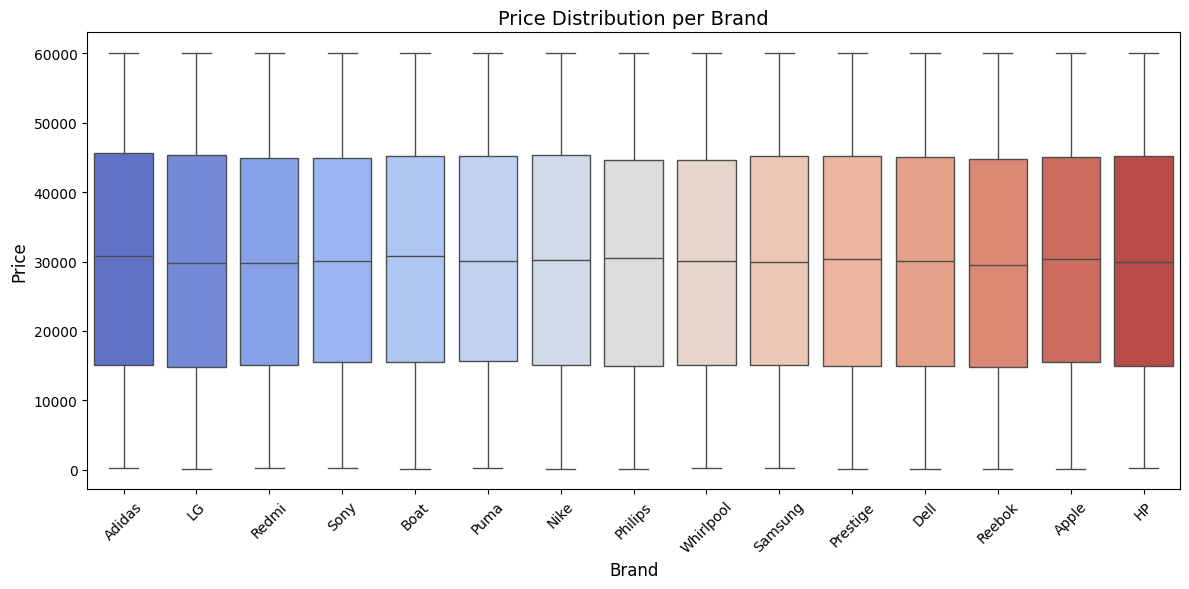

In [ ]:
# We want to see price distribution per brand

plt.figure(figsize=(12,6))
sns.boxplot(x='brand', y='price', data=df, palette='coolwarm')

plt.title("Price Distribution per Brand", fontsize=14)
plt.xlabel("Brand", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Let's have a look at the discounts distribution per bin
df['discount_bucket'] = pd.cut(
    df['discount_percent'],
    bins=[0, 5, 10, 20, 30, 40, 100],
    labels=['0–5%', '5–10%', '10–20%', '20–30%', '30–40%', '40%+']
)

df.groupby('discount_bucket')['units_sold'].mean().round()

/tmp/ipykernel_1568/3287863349.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('discount_bucket')['units_sold'].mean().round()


,units_sold
discount_bucket,
0–5%,2520.0
5–10%,2480.0
10–20%,2497.0
20–30%,2504.0
30–40%,2507.0
40%+,2522.0


This shows an interesting pattern: higher discounts could not increase sales as 20-30% as well as 0-5% lead to more sales.

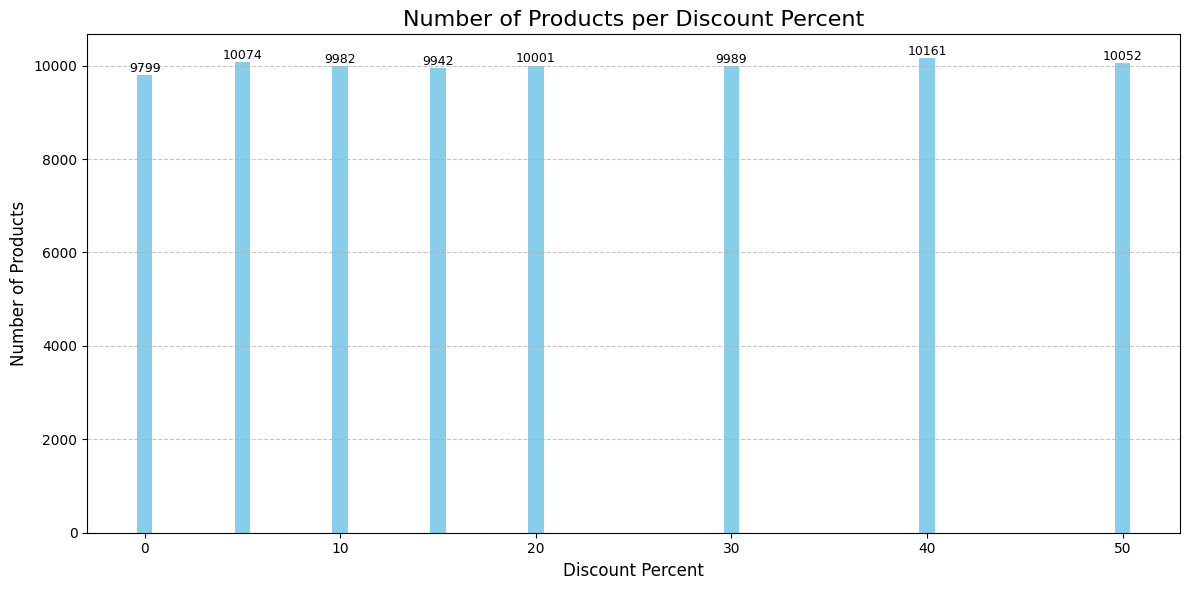

In [ ]:
# We want to see the discount distribution per products count
discount_counts = df.groupby('discount_percent')['product_name'].count().sort_index()

plt.figure(figsize=(12,6))
bars = plt.bar(discount_counts.index, discount_counts.values, color='skyblue')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, str(height),
             ha='center', va='bottom', fontsize=9)

plt.title("Number of Products per Discount Percent", fontsize=16)
plt.xlabel("Discount Percent", fontsize=12)
plt.ylabel("Number of Products", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
Discount distributed equally at +/-2%

In [ ]:
# Same approach, category and average this time
category_discount = (
    df.groupby(['category', 'discount_bucket'])['units_sold']
      .mean()
      .reset_index()
)
optimal_discount = (
    category_discount
    .sort_values(['category', 'units_sold'], ascending=[True, False])
    .groupby('category')
    .first()
)

optimal_discount.round().sort_values('units_sold', ascending=False)

/tmp/ipykernel_1568/70731913.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['category', 'discount_bucket'])['units_sold']


,discount_bucket,units_sold
category,,
Home & Kitchen,40%+,2601.0
Electronics,20–30%,2572.0
Toys,0–5%,2567.0
Sports,20–30%,2555.0
Appliances,5–10%,2540.0
Beauty,5–10%,2537.0
Fashion,40%+,2527.0
Mobiles,30–40%,2521.0


Home & Kitchen go heavy on discount
Toys are the top revenue category, good practice is there

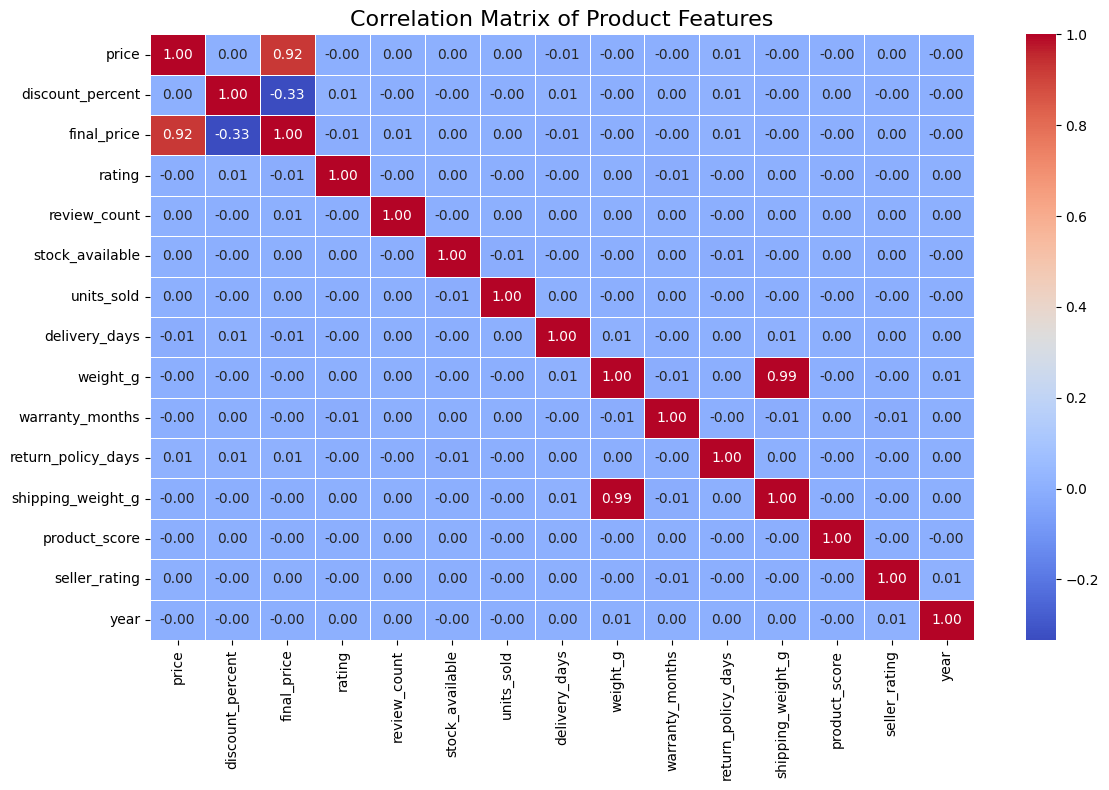

In [ ]:
# We want to see the correlations between features (heatmap format)
# Select relevant features
cols = [
    'price', 'discount_percent', 'final_price', 'rating', 'review_count',
    'stock_available', 'units_sold', 'delivery_days', 'weight_g',
    'warranty_months', 'return_policy_days', 'shipping_weight_g',
    'product_score', 'seller_rating', 'year'
]

# Convert listing_date to datetime and extract year if not already
df['listing_date'] = pd.to_datetime(df['listing_date'], errors='coerce')
df['year'] = df['listing_date'].dt.year

corr_matrix = df[cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix of Product Features", fontsize=16)
plt.tight_layout()
plt.show()

High correlation in the logistic but nothing relevant elsewehere

In [ ]:
# We want to see the product performance gap in terms of volume
df['expected_units'] = df.groupby('category')['units_sold'].transform('mean')

df['performance_gap'] = df['units_sold'] - df['expected_units']

underperformers = df[
    (df['performance_gap'] < 0) &
    (df['final_price'] > df.groupby('category')['final_price'].transform('median'))]

# showing now the top20 non-performing products
underperformers.sort_values('performance_gap', ascending=True).head(20)

,product_id,product_name,category,brand,seller,seller_city,price,discount_percent,final_price,rating,...,size,return_policy_days,is_returnable,payment_modes,shipping_weight_g,product_score,seller_rating,year,expected_units,performance_gap
67897,FKP0067898,Adidas Series 574,Home & Kitchen,Adidas,RetailHub,Mumbai,44309.61,15,37663.17,1.6,...,XL,0,False,"COD,UPI,CARD",4578.744151,72.93,4.39,2022,2526.267848,-2526.267848
32596,FKP0032597,Adidas Series 937,Home & Kitchen,Adidas,UrbanRetails,Mumbai,42299.04,15,35954.18,1.3,...,S,15,True,"COD,UPI,CARD",1925.593132,90.53,4.36,2021,2526.267848,-2526.267848
4211,FKP0004212,Prestige Prime 961,Appliances,Prestige,SuperMart,Pune,42093.38,0,42093.38,4.1,...,One Size,0,False,"COD,CARD",5068.971137,16.01,4.61,2022,2525.743255,-2524.743255
56921,FKP0056922,Reebok Model 617,Appliances,Reebok,MegaStore,Delhi,22997.95,0,22997.95,4.3,...,S,15,True,"COD,UPI,CARD",148.261192,71.27,4.87,2019,2525.743255,-2524.743255
72259,FKP0072260,Philips Series 947,Home & Kitchen,Philips,QuickShop,Hyderabad,36238.63,10,32614.77,3.5,...,One Size,0,False,"COD,CARD",1158.547382,87.80,4.49,2018,2526.267848,-2524.267848
78183,FKP0078184,Reebok Prime 713,Home & Kitchen,Reebok,ValueKart,Delhi,26152.22,10,23537.00,3.9,...,M,0,False,"COD,CARD",4364.878445,32.79,3.11,2022,2526.267848,-2523.267848
20176,FKP0020177,Philips Model 281,Home & Kitchen,Philips,UrbanRetails,Pune,53946.20,10,48551.58,4.7,...,S,7,True,"COD,CARD",1518.467501,70.00,4.76,2023,2526.267848,-2523.267848
12725,FKP0012726,Dell Ultra 982,Electronics,Dell,SuperMart,Ahmedabad,55760.89,5,52972.85,4.4,...,XL,10,True,"UPI,CARD",5628.169614,10.58,3.78,2018,2524.123259,-2523.123259
53738,FKP0053739,Adidas Series 601,Appliances,Adidas,BestBuy,Kolkata,48653.23,15,41355.25,3.6,...,XL,30,True,"UPI,CARD",583.432868,4.86,4.01,2020,2525.743255,-2522.743255
27420,FKP0027421,Puma Ultra 484,Appliances,Puma,BestBuy,Delhi,48288.15,10,43459.34,3.8,...,L,7,True,"CARD,Wallet",3993.426058,20.07,4.05,2018,2525.743255,-2521.743255


In [ ]:
Top 20 is located in the Home & Kitchen / Appliants category mostly
We see a performance gap (last column) of 2.5K in volume per SKU

In [ ]:
# We want to see the rating distribution within seller group
df['seller_rating_bucket'] = pd.cut(
    df['seller_rating'],
    bins=[0, 3, 4, 4.5, 5],
    labels=['<3', '3–4', '4–4.5', '4.5–5']
)

df.groupby('seller_rating_bucket')['units_sold'].mean().round()

/tmp/ipykernel_1568/2627852471.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('seller_rating_bucket')['units_sold'].mean().round()


,units_sold
seller_rating_bucket,
<3,2673.0
3–4,2511.0
4–4.5,2513.0
4.5–5,2494.0


This shows that lower product rating sells more that higher ones

In [ ]:
# We want to see the stock influence on product rating
df[['rating', 'stock_available']].corr(method='spearman')

,rating,stock_available
rating,1.000000,0.003917
stock_available,0.003917,1.000000


In [ ]:
There is none here

# Prediction

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

%matplotlib inline

sns.set(style='darkgrid')

Linear Regression R^2 Score: -0.0001
Linear Regression MSE: 2071914.0942


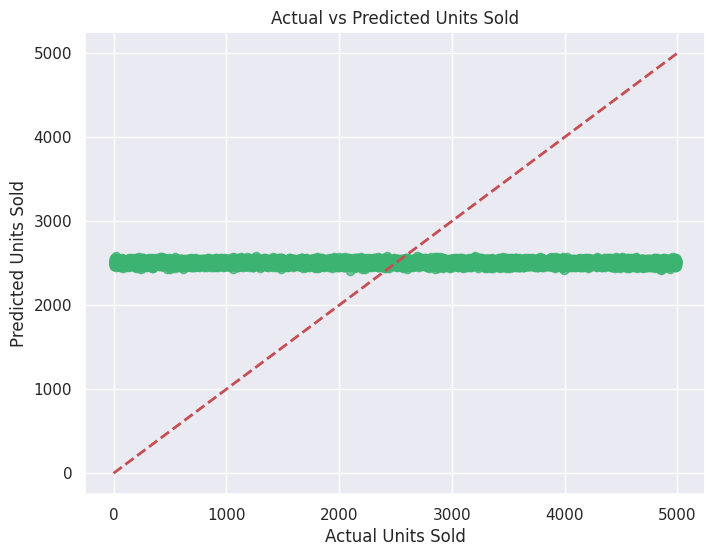

In [ ]:
# Choose target variable 'units_sold' and a subset of features that are likely to have features power
target = 'units_sold'

# List of potential features variables (using numeric columns only for simplicity)
predictors = ['price', 'discount_percent', 'final_price', 'rating', 'review_count',
              'stock_available', 'delivery_days', 'weight_g', 'warranty_months',
              'return_policy_days', 'shipping_weight_g', 'product_score', 'seller_rating']


df_model = df.copy()

# Split the data into train and test sets
X = df_model[predictors]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit a Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_pred = lr_model.predict(X_test)

# Evaluate performance
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'Linear Regression R^2 Score: {r2:.4f}')
print(f'Linear Regression MSE: {mse:.4f}')

# Optional: Plotting the true vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='mediumseagreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Units Sold')
plt.ylabel('Predicted Units Sold')
plt.title('Actual vs Predicted Units Sold')
plt.show()

R score shows no colse relationship with the features selected previously
On average, our model's predictions are off by about 1,439 rupees (avg 13€)

